In [1]:
import pandas as pd
import numpy as np
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import scipy.stats as stats
import arviz as az

sys.path.append(os.path.abspath('..'))
import utils
import mdp_utils
import process_data as dp

%load_ext autoreload
%autoreload 2

c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Failed to read module file 'C:\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _lo

In [8]:
NUM_VALS_PER_FEATURE = [3,2,3]
NUM_FEATURES = len(NUM_VALS_PER_FEATURE)
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 4
MAX_COUNT = 2
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CLUSTERS
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS

cluster_col = 'cluster_all'
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Motivation']
cluster_vars = ['likedness', 'usefulness', 'difficulty']

reward_cols = ["r_time", "r_likedness", "r_usefulness", "r_expert"]
obj_names = ["Time Appropriateness", "Fun", "Perceived Usefulness", "Expert Usefulness"]

NUM_OBJECTIVES = len(reward_cols)

In [3]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)

df, initial_distribution = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, cluster_col, MAX_COUNT, NUM_CLUSTERS)

Number of samples after processing: 3111


In [4]:
def evaluate_dynamics(test_df, P_comp, R, P, R_action_only, P_comp_action_only, p_comp_overall):
    mse_rewards = []
    l1_rewards = []
    l1_rewards_action_only = []
    next_state_likelihoods = []
    equal_state_likelihoods = []
    completion_likelihoods = []
    completion_likelihoods_action_only = []
    completion_likelihoods_overall = []
    for t in range(len(test_df)):
        # True values
        s_t = test_df.iloc[t]['s_idx']
        c_t = test_df.iloc[t]['c_idx']
        a_t = test_df.iloc[t][cluster_col]
        s_t_next = test_df.iloc[t]['sp_idx']
        r_t = test_df.iloc[t][reward_cols].values
        completed = test_df.iloc[t]['completed']

        # Reward predictions
        r_pred = R[s_t, c_t, a_t]
        r_pred_action_only = R_action_only[a_t]
        mse_reward = np.mean((r_t - r_pred)**2)
        l1_reward = np.abs(r_t - r_pred)
        mse_rewards.append(mse_reward)
        l1_rewards.append(l1_reward)
        l1_rewards_action_only.append(np.abs(r_t - r_pred_action_only))

        # Next state likelihood
        P_s_t_next = P[s_t, a_t, s_t_next]
        next_state_likelihoods.append(P_s_t_next)
        equal_state_likelihoods.append(s_t_next == s_t)

        # Completion likelihood
        P_comp_pred = P_comp[s_t, a_t]
        P_comp_pred_action_only = P_comp_action_only[a_t]
        completion_likelihood = P_comp_pred if completed else (1 - P_comp_pred)
        completion_likelihood_action_only = P_comp_pred_action_only if completed else (1 - P_comp_pred_action_only)
        completion_likelihood_overall = p_comp_overall if completed else (1 - p_comp_overall)
        completion_likelihoods.append(completion_likelihood)
        completion_likelihoods_action_only.append(completion_likelihood_action_only)
        completion_likelihoods_overall.append(completion_likelihood_overall)

    return mse_rewards, l1_rewards, l1_rewards_action_only, next_state_likelihoods, equal_state_likelihoods, completion_likelihoods, completion_likelihoods_action_only, completion_likelihoods_overall

In [5]:
all_users = df['user_id'].unique()
print("Number of users:", len(all_users))

all_mse_rewards = []
all_l1_rewards = []
all_l1_rewards_action_only = []
all_next_state_likelihoods = []
all_equal_state_likelihoods = []
all_completion_likelihoods = []
all_completion_likelihoods_action_only = []
all_completion_likelihoods_overall = []
for test_user in all_users:

    train_df = df[df['user_id'] != test_user]
    test_df = df[df['user_id'] == test_user]
    
    P_comp = mdp_utils.compute_completion_probabilities_clustered(
        train_df, cluster_col, NUM_USER_STATES, NUM_ACTIONS, 
        num_clusters=NUM_CLUSTERS, use_clusters=True
    )
    
    R = mdp_utils.compute_rewards(train_df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, cluster_col)
    R_action_only = mdp_utils.compute_avg_rewards(train_df, NUM_ACTIONS, cluster_col, reward_cols)
    
    P = mdp_utils.compute_transition_probabilities_clustered(
        train_df, NUM_USER_STATES, NUM_ACTIONS, cluster_col, 
        num_clusters=NUM_CLUSTERS, use_clusters=True
    )
    
    P_comp_action_only = mdp_utils.compute_completion_probabilities_action_only(
        train_df, NUM_ACTIONS, cluster_col
    )

    p_comp_overall = train_df['completed'].mean()
    
    mse_rewards, l1_rewards, l1_rewards_action_only, next_state_likelihoods, equal_state_likelihoods, completion_likelihoods, completion_likelihoods_action_only, completion_likelihoods_overall = evaluate_dynamics(test_df, P_comp, R, P, R_action_only, P_comp_action_only, p_comp_overall)
    all_mse_rewards.append(mse_rewards)
    all_l1_rewards.append(l1_rewards)
    all_l1_rewards_action_only.append(l1_rewards_action_only)
    all_next_state_likelihoods.append(next_state_likelihoods)
    all_equal_state_likelihoods.append(equal_state_likelihoods)
    all_completion_likelihoods.append(completion_likelihoods)
    all_completion_likelihoods_action_only.append(completion_likelihoods_action_only)
    all_completion_likelihoods_overall.append(completion_likelihoods_overall)
mean_mse_rewards = np.mean([np.mean(mse) for mse in all_mse_rewards])
mean_l1_rewards = np.mean([np.mean(l1, axis=0) for l1 in all_l1_rewards], axis=0)
mean_l1_rewards_action_only = np.mean([np.mean(l1, axis=0) for l1 in all_l1_rewards_action_only], axis=0)
mean_next_state_likelihood = np.mean([np.mean(ns) for ns in all_next_state_likelihoods])
mean_equal_state_likelihood = np.mean([np.mean(es) for es in all_equal_state_likelihoods])
mean_completion_likelihood = np.mean([np.mean(cl) for cl in all_completion_likelihoods])
mean_completion_likelihood_action_only = np.mean([np.mean(cl) for cl in all_completion_likelihoods_action_only])
mean_completion_likelihood_overall = np.mean([np.mean(cl) for cl in all_completion_likelihoods_overall])
print(f"L1-error per objective: {', '.join(f'{m:.4f}' for m in mean_l1_rewards)}")
print(f"L1-error (action-only) per objective: {', '.join(f'{m:.4f}' for m in mean_l1_rewards_action_only)}")
print(f"Avg Next State Likelihood: {mean_next_state_likelihood:.4f}, Avg Equal State Likelihood: {mean_equal_state_likelihood:.4f}, Avg Completion Likelihood: {mean_completion_likelihood:.4f}")
print(f"Avg Completion Likelihood (action-only): {mean_completion_likelihood_action_only:.4f}")
print(f"Avg Completion Likelihood (overall): {mean_completion_likelihood_overall:.4f}")


Number of users: 309
L1-error per objective: 0.4353, 0.3418, 0.3404, 0.2174
L1-error (action-only) per objective: 0.4391, 0.3465, 0.3444, 0.2265
Avg Next State Likelihood: 0.1141, Avg Equal State Likelihood: 0.2099, Avg Completion Likelihood: 0.5543
Avg Completion Likelihood (action-only): 0.5503
Avg Completion Likelihood (overall): 0.5400


### Reward function evaluation
To evaluate our learned reward function, we compare it against using only the action to predict the reward.

Difference in mean L1 error (State-Action - Action-Only) per objective: -0.0038, -0.0047, -0.0040, -0.0091
95% CI for difference in mean L1 error for Time Appropriateness: [-0.0168, 0.0092]
95% HDI for difference in mean L1 error for Time Appropriateness: [-0.0164, 0.0096]
Probability that State-Action model has lower L1 error than Action-Only model for Time Appropriateness: 0.7171
Probability that State-Action model has lower L1 error than Action-Only model for Time Appropriateness (using normal approximation): 0.7166
95% CI for difference in mean L1 error for Fun: [-0.0176, 0.0082]
95% HDI for difference in mean L1 error for Fun: [-0.0178, 0.0074]
Probability that State-Action model has lower L1 error than Action-Only model for Fun: 0.7613
Probability that State-Action model has lower L1 error than Action-Only model for Fun (using normal approximation): 0.7632
95% CI for difference in mean L1 error for Perceived Usefulness: [-0.0169, 0.0088]
95% HDI for difference in mean L1 error fo

<Figure size 1200x600 with 0 Axes>

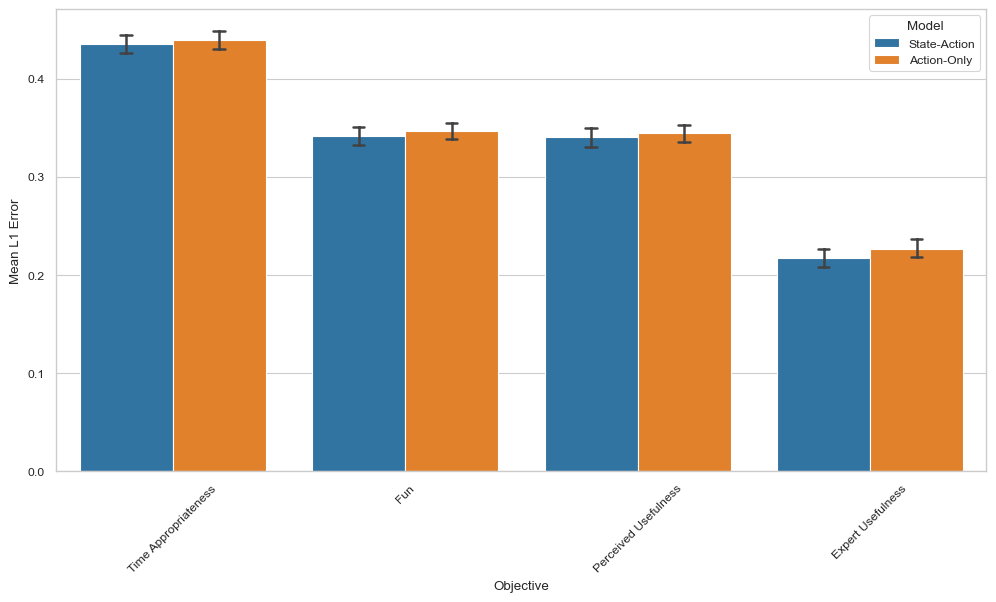

In [9]:
user_means_array = np.array([np.mean(l1, axis=0) for l1 in all_l1_rewards], dtype=np.float64)
std_l1_rewards = np.std(user_means_array, axis=0)
sem_l1_rewards = std_l1_rewards / np.sqrt(len(all_users))
user_means_array_action_only = np.array([np.mean(l1, axis=0) for l1 in all_l1_rewards_action_only], dtype=np.float64)
std_l1_rewards_action_only = np.std(user_means_array_action_only, axis=0)
sem_l1_rewards_action_only = std_l1_rewards_action_only / np.sqrt(len(all_users))

diff_in_means = mean_l1_rewards - mean_l1_rewards_action_only
print(f"Difference in mean L1 error (State-Action - Action-Only) per objective: {', '.join(f'{diff:.4f}' for diff in diff_in_means)}")
sem_diff = np.sqrt(sem_l1_rewards**2 + sem_l1_rewards_action_only**2)
for i in range(len(obj_names)):
    ci_low, ci_high = stats.t.interval(0.95, df=(len(all_users)-1)*2, loc=diff_in_means[i], scale=sem_diff[i])
    print(f"95% CI for difference in mean L1 error for {obj_names[i]}: [{ci_low:.4f}, {ci_high:.4f}]")
    posterior_samples = np.random.normal(loc=diff_in_means[i], scale=sem_diff[i], size=10000)
    hdi = az.hdi(posterior_samples, hdi_prob=0.95)
    print(f"95% HDI for difference in mean L1 error for {obj_names[i]}: [{hdi[0]:.4f}, {hdi[1]:.4f}]")
    prob_a_better = np.mean(posterior_samples < 0)
    print(f"Probability that State-Action model has lower L1 error than Action-Only model for {obj_names[i]}: {prob_a_better:.4f}")
    prob_a_better_cdf = stats.norm.cdf(0, loc=diff_in_means[i], scale=sem_diff[i])
    print(f"Probability that State-Action model has lower L1 error than Action-Only model for {obj_names[i]} (using normal approximation): {prob_a_better_cdf:.4f}")

print(f"L1-error per objective: {', '.join(f'{m:.4f} ± {s:.4f}' for m, s in zip(mean_l1_rewards, std_l1_rewards))}")
print(f"L1-error (action-only) per objective: {', '.join(f'{m:.4f} ± {s:.4f}' for m, s in zip(mean_l1_rewards_action_only, std_l1_rewards_action_only))}")

rows = []
for i, l1 in enumerate(all_l1_rewards):
    user_mean = np.mean(l1, axis=0)
    for obj_idx, obj_name in enumerate(obj_names):
        rows.append({'Objective': obj_name, 'Mean L1 Error': user_mean[obj_idx], 'Model': 'State-Action'})

for i, l1 in enumerate(all_l1_rewards_action_only):
    user_mean = np.mean(l1, axis=0)
    for obj_idx, obj_name in enumerate(obj_names):
        rows.append({'Objective': obj_name, 'Mean L1 Error': user_mean[obj_idx], 'Model': 'Action-Only'})

full_df = pd.DataFrame(rows)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(12, 6))
sns.barplot(data=full_df, x='Objective', y='Mean L1 Error', hue='Model', capsize=.1)

plt.xticks(rotation=45)
plt.show()

### User state transition dynamics evaluation

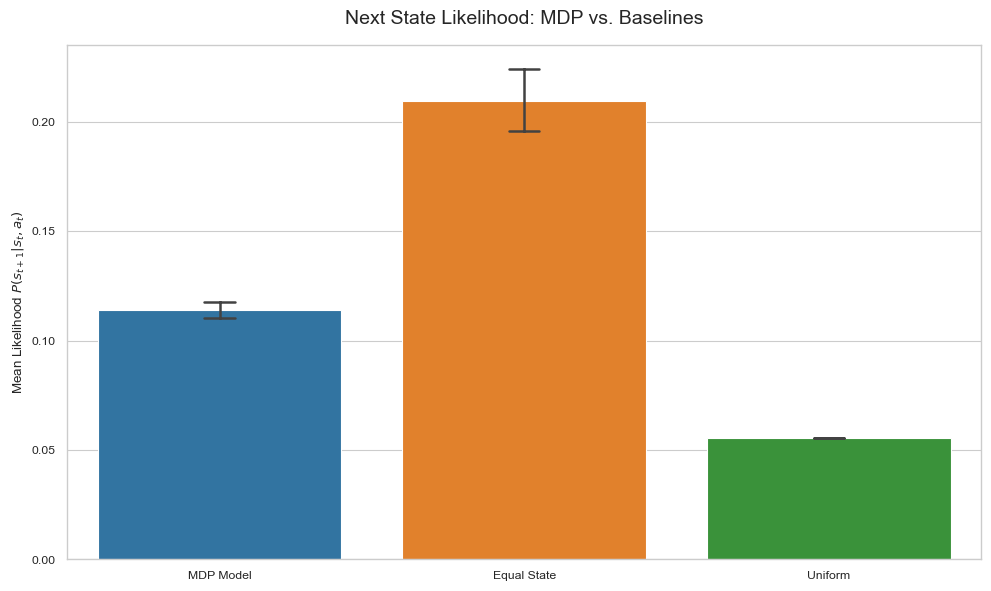

In [10]:
uniform_prob = 1.0 / NUM_USER_STATES

rows = []
for next_list, equal_list in zip(all_next_state_likelihoods, all_equal_state_likelihoods):
    for p_next, p_equal in zip(next_list, equal_list):
        rows.append({'Model': 'MDP Model', 'Likelihood': p_next})
        rows.append({'Model': 'Equal State', 'Likelihood': float(p_equal)})
        rows.append({'Model': 'Uniform', 'Likelihood': uniform_prob})

df_plot = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=df_plot, 
    x='Model', 
    y='Likelihood', 
    hue='Model',
    capsize=.1,           # Adds the horizontal caps to the error bars
    errorbar=('ci', 95)    # Explicitly set 95% Confidence Interval
)

# Style the plot
plt.title('Next State Likelihood: MDP vs. Baselines', fontsize=14, pad=15)
plt.ylabel('Mean Likelihood $P(s_{t+1} | s_t, a_t)$')
plt.xlabel('') # Model names are self-explanatory
plt.tight_layout()
plt.show()

### Completion probabilities evaluation

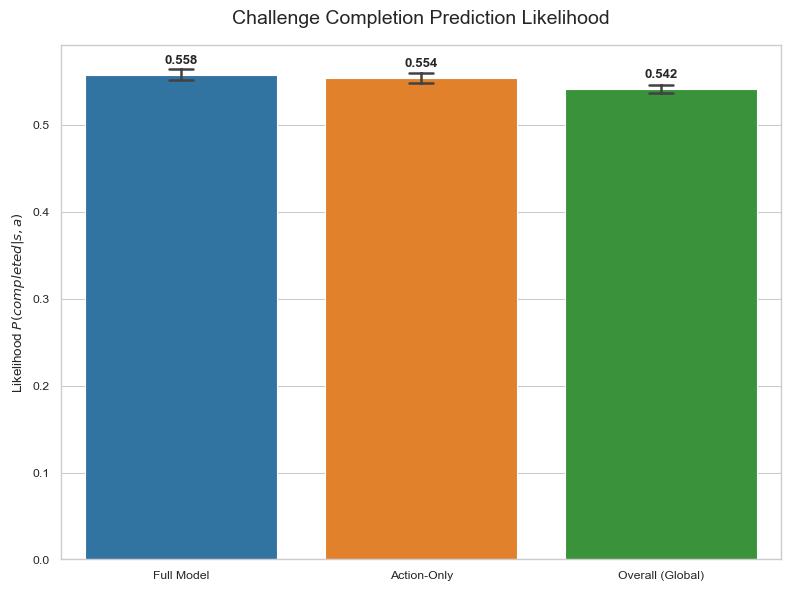

In [11]:
rows = []

# Iterate through the lists of results per user
for cl_list, cl_ao_list, cl_ov_list in zip(
    all_completion_likelihoods, 
    all_completion_likelihoods_action_only, 
    all_completion_likelihoods_overall
):
    for p_cl, p_cl_ao, p_cl_ov in zip(cl_list, cl_ao_list, cl_ov_list):
        rows.append({'Model': 'Full Model', 'Likelihood': p_cl})
        rows.append({'Model': 'Action-Only', 'Likelihood': p_cl_ao})
        rows.append({'Model': 'Overall (Global)', 'Likelihood': p_cl_ov})

df_comp_final = pd.DataFrame(rows)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=df_comp_final, 
    x='Model', 
    y='Likelihood', 
    hue='Model',
    capsize=.1,
    errorbar=('ci', 95) # 95% Confidence Interval
)

plt.title('Challenge Completion Prediction Likelihood', fontsize=14, pad=15)
plt.ylabel('Likelihood $P(completed | s, a)$')
plt.xlabel('')

# Add mean labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()